Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

n_samples = 300  # Total points
centers = [[-1, -1], [2, 2]]  # Cluster centers for diagonal separation
cluster_std = 1.0  # Standard deviation for overlap

X, y = make_blobs(
    n_samples=n_samples,
    centers=centers,
    n_features=2,
    cluster_std=cluster_std,
    random_state=80  # For reproducibility
)

Split train and test sets

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

Naive Bayes

Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        47
           1       0.86      0.88      0.87        43

    accuracy                           0.88        90
   macro avg       0.88      0.88      0.88        90
weighted avg       0.88      0.88      0.88        90



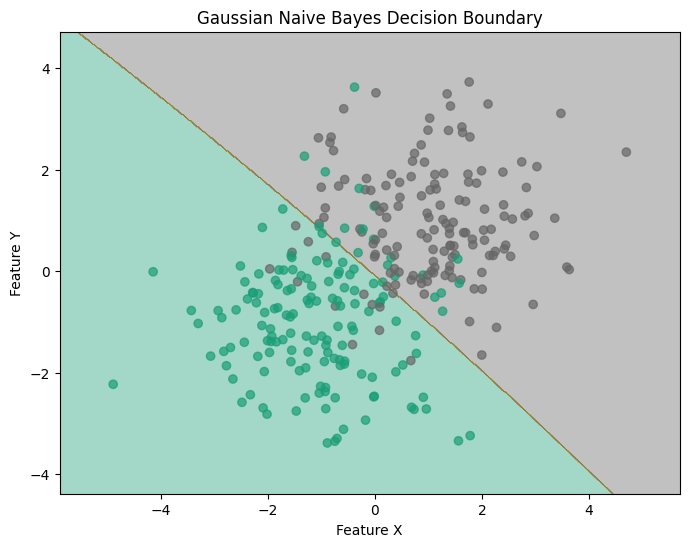

In [5]:
from sklearn.naive_bayes import GaussianNB  # For continuous features
# from sklearn.naive_bayes import MultinomialNB  # Uncomment for discrete/count data
from sklearn.metrics import accuracy_score, classification_report

# Step 3: Train Gaussian Naive Bayes (for continuous data)
model = GaussianNB()
# If using MultinomialNB (for counts): model = MultinomialNB()
# Note: For Multinomial, X must be non-negative integers; adjust data if needed.

model.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

# Optional: Plot decision boundary
# Create a mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on mesh
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='Dark2')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='Dark2', alpha=0.7)
plt.title("Gaussian Naive Bayes Decision Boundary")
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.show()

Logistic Regression

Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        47
           1       0.86      0.88      0.87        43

    accuracy                           0.88        90
   macro avg       0.88      0.88      0.88        90
weighted avg       0.88      0.88      0.88        90



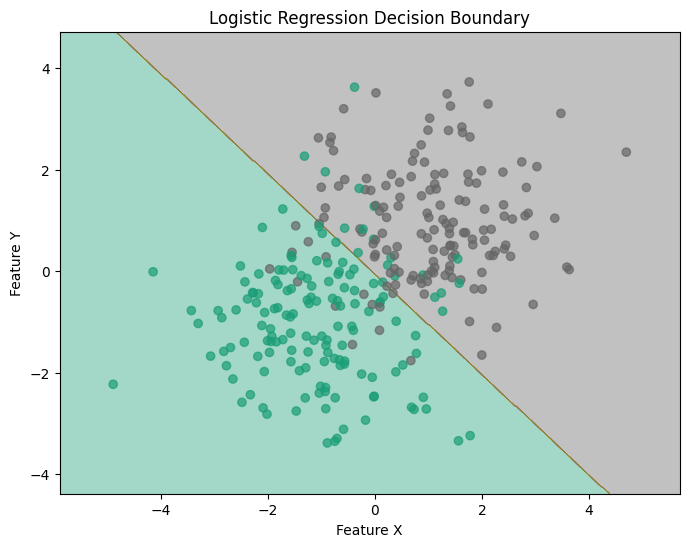

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression  # For logistic regression
from sklearn.metrics import accuracy_score, classification_report



# Step 3: Train Logistic Regression
model = LogisticRegression()
# Optional: Add regularization with C=1.0 (inverse of regularization strength)

model.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

# Optional: Plot decision boundary
# Create a mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on mesh
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='Dark2')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='Dark2', alpha=0.7)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.show()